In [31]:
data_path="../../../workdir/yahoofinance_day_prices_dj30"
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [32]:
import os
import pandas as pd

# Get the list of CSV files
files = os.listdir(data_path)
montly_return_data={}
# Loop through each file and process it
for file in files:
    filepath = os.path.join(data_path, file)
    if file.endswith(".csv") and os.path.isfile(filepath):
        print(f"Processing file: {file}")
        # Read the CSV file
        try:
            data = pd.read_csv(filepath)
        except pd.errors.EmptyDataError:
            print(f"Skipping empty file: {file}")
            continue
        
        # Ensure the data has a 'Date' column and it's in datetime format
        if 'Date' in data.columns:
            data['Date'] = pd.to_datetime(data['Date'])
            data.set_index('Date', inplace=True)
        else:
            print(f"File {file} does not have a 'Date' column. Skipping...")
            continue
        
        # Ensure there is a 'Close' column
        if 'Close' in data.columns:
            # Resample to monthly frequency, taking the last close price of the month
            monthly_close = data['Close'].resample('ME').last()
            # cast to numeric
            monthly_close = pd.to_numeric(monthly_close, errors='coerce')
            # print(monthly_close)
            
            # Calculate monthly return
            monthly_return = monthly_close.pct_change().dropna()
            
            # Save or display the result
            print(f"Monthly returns for {file}:\n", monthly_return.head())
            # save the monthly return data into the dictionary
            montly_return_data[file]=monthly_return
        else:
            print(f"File {file} does not have a 'Close' column. Skipping...")
# merge all the monthly returns of the files into one dataframe
df=pd.DataFrame(montly_return_data)
# print(df.head())
# calculate the non-nan count of each column
non_nan_count=df.count()
print(non_nan_count)

Processing file: PG.csv
Monthly returns for PG.csv:
 Date
2000-02-29   -0.130489
2000-03-31   -0.354196
2000-04-30    0.052863
2000-05-31    0.112971
2000-06-30   -0.146617
Freq: ME, Name: Close, dtype: float64
Processing file: IBM.csv
Monthly returns for IBM.csv:
 Date
2000-02-29   -0.084632
2000-03-31    0.152068
2000-04-30   -0.058078
2000-05-31   -0.037556
2000-06-30    0.020967
Freq: ME, Name: Close, dtype: float64
Processing file: NKE.csv
Monthly returns for NKE.csv:
 Date
2000-02-29   -0.375000
2000-03-31    0.393406
2000-04-30    0.096215
2000-05-31   -0.012950
2000-06-30   -0.071428
Freq: ME, Name: Close, dtype: float64
Processing file: AMGN.csv
Monthly returns for AMGN.csv:
 Date
2000-02-29    0.070658
2000-03-31   -0.099908
2000-04-30   -0.087576
2000-05-31    0.136161
2000-06-30    0.104126
Freq: ME, Name: Close, dtype: float64
Processing file: V.csv
Monthly returns for V.csv:
 Date
2008-04-30    0.338198
2008-05-31    0.034871
2008-06-30   -0.058476
2008-07-31   -0.101464


In [33]:
# read the macroeconomic data
# save the merged data to a csv file
macro_data_folder = "../../../datasets/macro_processed"
macro_data_name = "macro_data.csv"
macro_data=pd.read_csv(os.path.join(macro_data_folder,macro_data_name))

In [34]:
print(macro_data.head())

         Date  exp.real.short.rate.5  exp.inflation.5  real.term.prem.5  \
0  2000-01-01               2.116505         3.309330          0.982340   
1  2000-02-01               2.224655         3.272955          0.955350   
2  2000-03-01               2.215509         3.216578          0.863452   
3  2000-04-01               2.147000         3.150437          0.779137   
4  2000-05-01               2.340100         3.256609          0.886268   

   inflation.risk.prem.5  tips.liq.prem.5  nominal.yield.raw.5  \
0               0.135650         1.295855             6.524823   
1               0.151100         1.193895             6.605611   
2               0.125591         1.177374             6.420187   
3               0.105610         1.162947             6.180498   
4               0.127059         1.021400             6.603662   

   nominal.yield.fitted.5  ic.raw.5  ic.fitted.5  ...   lmci  CPIAUCSL  \
0                6.543825  2.181758     2.149125  ...  1.134     169.3   
1   

        Date    PG.csv   IBM.csv   NKE.csv  AMGN.csv  V.csv   MCD.csv  \
0 2000-02-29 -0.130489 -0.084632 -0.375000  0.070658    NaN -0.150502   
1 2000-03-31 -0.354196  0.152068  0.393406 -0.099908    NaN  0.177165   
2 2000-04-30  0.052863 -0.058078  0.096215 -0.087576    NaN  0.018395   
3 2000-05-31  0.112971 -0.037556 -0.012950  0.136161    NaN -0.059113   
4 2000-06-30 -0.146617  0.020967 -0.071428  0.104126    NaN -0.080279   

    AXP.csv  INTC.csv    GS.csv  ...   CAT.csv   TRV.csv   CVX.csv  CSCO.csv  \
0 -0.185508  0.142135  0.009550  ... -0.173785 -0.258799 -0.106876  0.207192   
1  0.109921  0.167588  0.137838  ...  0.124777  0.525140  0.237657  0.169740   
2  0.003777 -0.038844 -0.114014  ...  0.000000  0.043956 -0.079108 -0.103274   
3  0.083612 -0.016757 -0.211126  ... -0.030111  0.052632  0.085903 -0.178724   
4 -0.034722  0.072180  0.288445  ... -0.114379 -0.090000 -0.082488  0.116356   

    JPM.csv   UNH.csv   HON.csv   WMT.csv  year  month  
0 -0.013168 -0.035377  

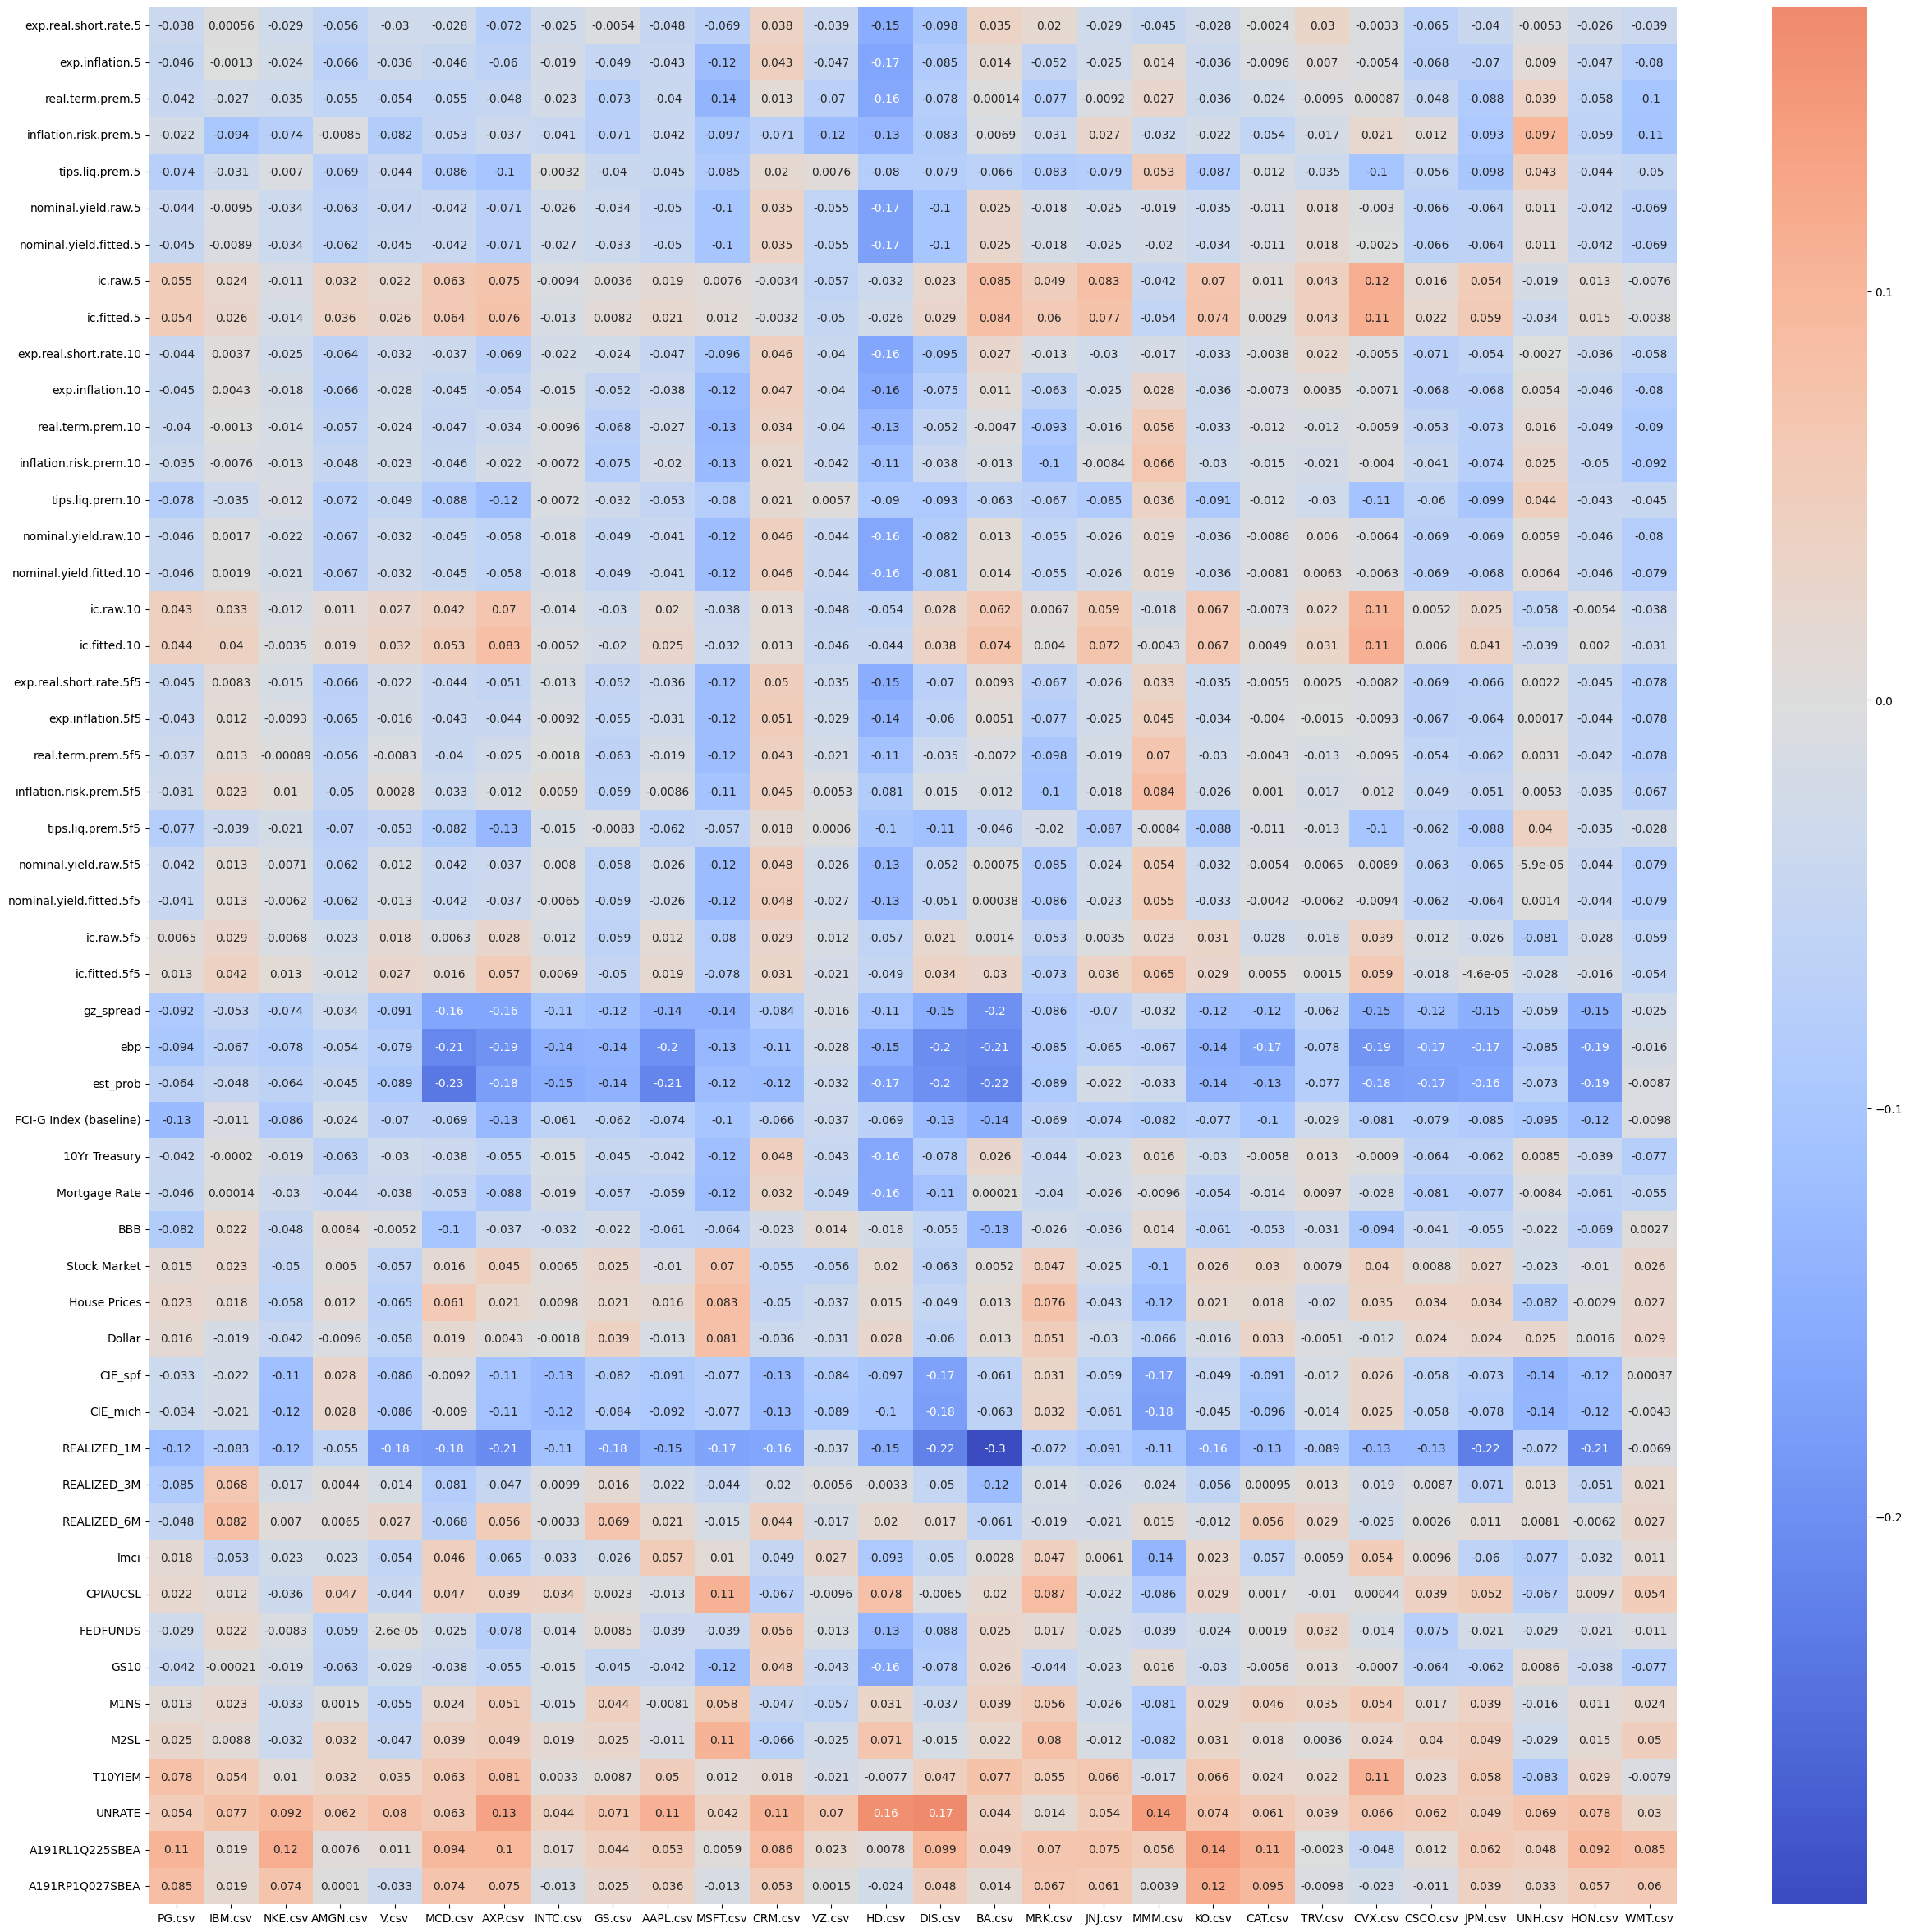

In [35]:
import pandas as pd

# Initialize a dictionary to store IC results
ic_data = {}
# reset the index of df as the Date column
df.reset_index(inplace=True)
# Add 'year' and 'month' columns to align data
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
macro_data['Date'] = pd.to_datetime(macro_data['Date'])
macro_data['year'] = macro_data['Date'].dt.year
macro_data['month'] = macro_data['Date'].dt.month
print(df.head())
print(macro_data.head())

# Loop through each ETF column in the DataFrame
for column in df.columns:
    if column not in ['Date', 'year', 'month']:  # Skip non-relevant columns
        # Align macroeconomic data and ETF returns by year and month
        merged_data = pd.merge(
            df[['year', 'month', column]],
            macro_data,
            on=['year', 'month']
        )
        
        # Calculate IC (correlation coefficient) for each macroeconomic variable
        correlations = merged_data.corr(numeric_only=True)[column].drop(
            ['year', 'month', column, 'Date'], errors='ignore'
        )
        
        # Store results in the dictionary
        ic_data[column] = correlations

# Convert IC dictionary to DataFrame
ic_df = pd.DataFrame(ic_data)

# Display the top of the IC DataFrame
print(ic_df.head())
# Save the IC DataFrame to a CSV file
ic_df.to_csv("return_macro_ic_results.csv")
# Plot the IC DataFrame as a heatmap
plt.figure(figsize=(30, 30))
sns.heatmap(ic_df, annot=True, cmap='coolwarm', center=0)
plt.savefig("return_macro_ic_heatmap.png", bbox_inches='tight')
plt.show()

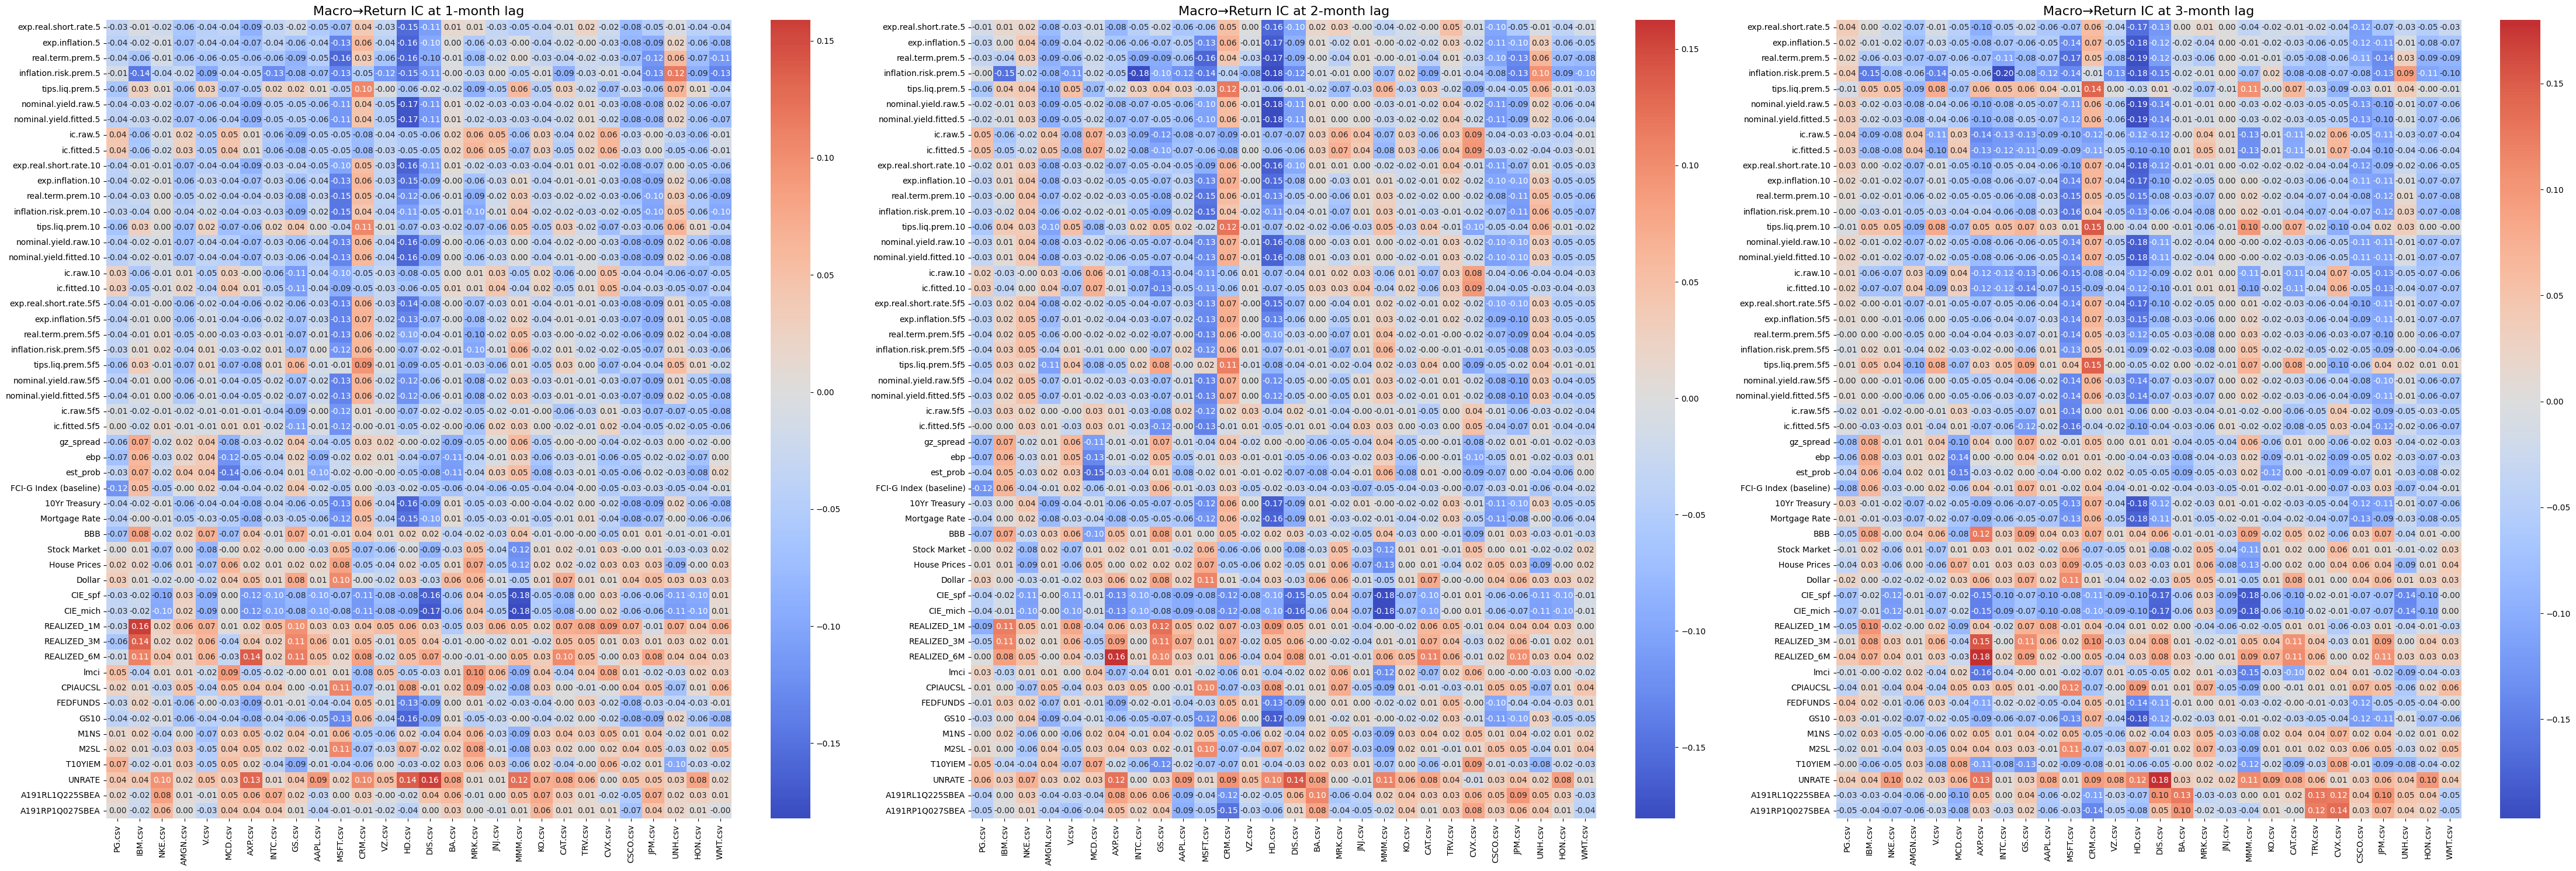


=== Lagged IC Summary (mean |IC| across stocks) ===
                          lag_0m  lag_1m  lag_2m  lag_3m
REALIZED_1M                0.137   0.052   0.045   0.035
ebp                        0.126   0.043   0.037   0.039
est_prob                   0.120   0.047   0.041   0.041
gz_spread                  0.103   0.032   0.035   0.036
CIE_mich                   0.078   0.073   0.074   0.078
FCI-G Index (baseline)     0.077   0.037   0.037   0.033
CIE_spf                    0.077   0.071   0.074   0.078
UNRATE                     0.076   0.060   0.052   0.062
A191RL1Q225SBEA            0.058   0.032   0.050   0.055
tips.liq.prem.10           0.058   0.042   0.044   0.044
inflation.risk.prem.5      0.057   0.070   0.077   0.088
tips.liq.prem.5            0.056   0.042   0.044   0.044
tips.liq.prem.5f5          0.053   0.039   0.040   0.043
real.term.prem.5           0.051   0.060   0.059   0.071
Mortgage Rate              0.049   0.048   0.050   0.059
nominal.yield.raw.5        0.046   

In [36]:
# Lagged IC analysis: shift macro data by 1-3 months to reveal predictive relationships
# A positive lag means macro leads stock returns (macro at month t vs return at month t+lag)

lag_months = [1, 2, 3]
lagged_ic_results = {}

for lag in lag_months:
    ic_lag = {}
    for column in df.columns:
        if column not in ['Date', 'year', 'month']:
            # Shift macro data forward by `lag` months (macro at t predicts return at t+lag)
            macro_shifted = macro_data.copy()
            macro_shifted['month'] = macro_shifted['month'] + lag
            # Handle month overflow into next year
            macro_shifted['year'] = macro_shifted['year'] + (macro_shifted['month'] - 1) // 12
            macro_shifted['month'] = ((macro_shifted['month'] - 1) % 12) + 1

            merged = pd.merge(
                df[['year', 'month', column]],
                macro_shifted,
                on=['year', 'month']
            )
            if len(merged) < 5:
                continue
            corr = merged.corr(numeric_only=True)[column].drop(
                ['year', 'month', column, 'Date'], errors='ignore'
            )
            ic_lag[column] = corr
    lagged_ic_results[lag] = pd.DataFrame(ic_lag)

# Plot lagged IC heatmaps side by side
fig, axes = plt.subplots(1, 3, figsize=(45, 15))
for i, lag in enumerate(lag_months):
    lag_df = lagged_ic_results[lag]
    sns.heatmap(lag_df, annot=True, cmap='coolwarm', center=0, ax=axes[i], fmt='.2f')
    axes[i].set_title(f'Macro→Return IC at {lag}-month lag', fontsize=16)
plt.tight_layout()
plt.savefig("return_macro_lagged_ic_heatmaps.png", bbox_inches='tight')
plt.show()

# Print summary: which macro variables gain predictive power at which lag
print("\n=== Lagged IC Summary (mean |IC| across stocks) ===")
summary_rows = []
for lag in lag_months:
    lag_df = lagged_ic_results[lag]
    mean_abs_ic = lag_df.abs().mean(axis=1)
    summary_rows.append(mean_abs_ic.rename(f'lag_{lag}m'))
summary = pd.concat(summary_rows, axis=1)
# Add contemporaneous IC for comparison
contemp_ic = ic_df.abs().mean(axis=1).rename('lag_0m')
summary = pd.concat([contemp_ic, summary], axis=1)
print(summary.sort_values('lag_0m', ascending=False).round(3))

low_correlation_stocks: Index(['exp.real.short.rate.5', 'exp.inflation.5', 'nominal.yield.raw.5',
       'nominal.yield.fitted.5', 'ic.raw.5', 'ic.fitted.5',
       'exp.real.short.rate.10', 'exp.inflation.10', 'real.term.prem.10',
       'inflation.risk.prem.10', 'nominal.yield.raw.10',
       'nominal.yield.fitted.10', 'ic.raw.10', 'ic.fitted.10',
       'exp.real.short.rate.5f5', 'exp.inflation.5f5', 'real.term.prem.5f5',
       'inflation.risk.prem.5f5', 'nominal.yield.raw.5f5',
       'nominal.yield.fitted.5f5', 'ic.raw.5f5', 'ic.fitted.5f5',
       '10Yr Treasury', 'Mortgage Rate', 'BBB', 'Stock Market', 'House Prices',
       'Dollar', 'REALIZED_3M', 'REALIZED_6M', 'lmci', 'CPIAUCSL', 'FEDFUNDS',
       'GS10', 'M1NS', 'M2SL', 'T10YIEM', 'A191RP1Q027SBEA'],
      dtype='object')
low_correlation_macro: Index(['PG.csv', 'IBM.csv', 'NKE.csv', 'AMGN.csv', 'V.csv', 'INTC.csv',
       'GS.csv', 'AAPL.csv', 'VZ.csv', 'JNJ.csv', 'CAT.csv', 'TRV.csv',
       'CVX.csv', 'UNH.csv', 'WMT.cs

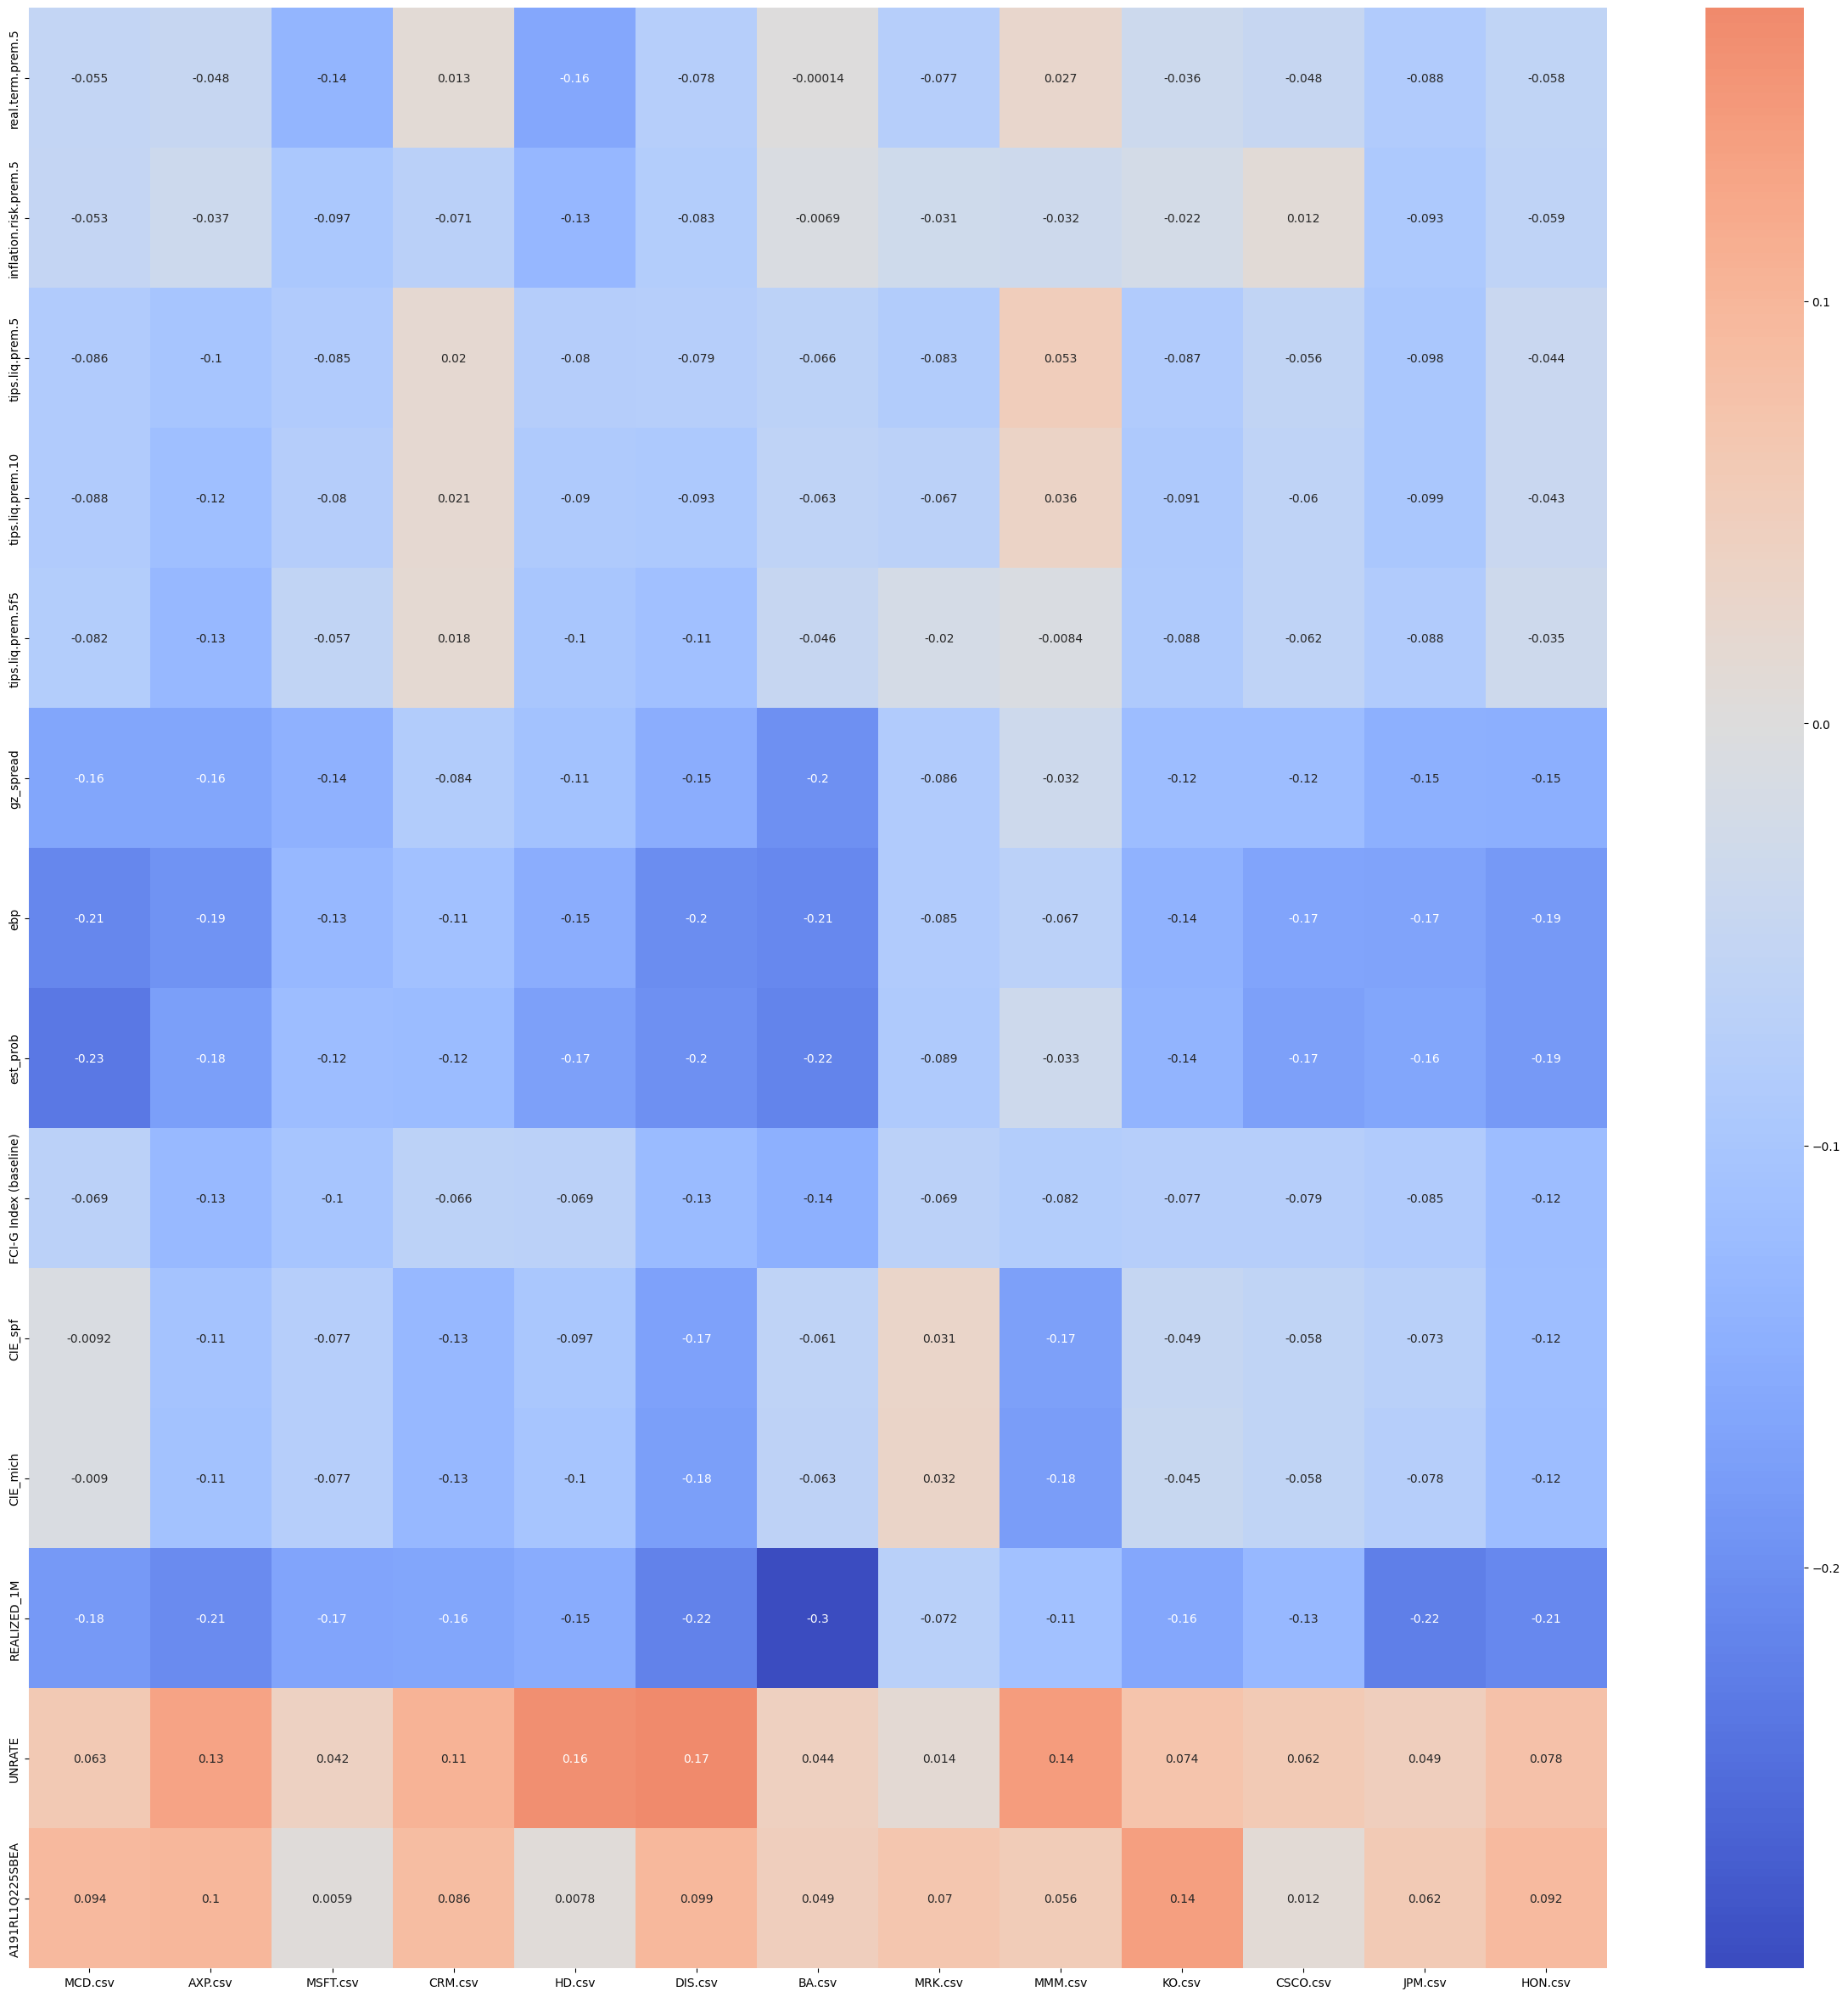

In [37]:
# display the stocks / macro variables which have low correlation for all macro variables / stocks
# Get stocks with low correlation (row-wise operation)
low_correlation_stocks = ic_df.loc[ic_df.abs().mean(axis=1) < 0.05].index
print("low_correlation_stocks:", low_correlation_stocks)

# Get macro variables with low correlation (column-wise operation)
low_correlation_macro = ic_df.columns[ic_df.abs().mean(axis=0) < 0.05]
print("low_correlation_macro:", low_correlation_macro)

# save the low correlation stocks and macro variables to a file
with open("low_correlation_stocks.txt", "w") as f:
    f.write("\n".join(low_correlation_stocks))
with open("low_correlation_macro.txt", "w") as f:
    f.write("\n".join(low_correlation_macro))

# remove the low correlation stocks and macro variables from the ic_df
ic_df.drop(index=low_correlation_stocks, columns=low_correlation_macro, inplace=True)
# Plot the IC DataFrame as a heatmap
plt.figure(figsize=(30, 30))
sns.heatmap(ic_df, annot=True, cmap='coolwarm', center=0)
plt.savefig("return_macro_ic_heatmap_filtered.png", bbox_inches='tight')
plt.show()

In [38]:
# rank the stocks and macro variables based on the average correlation
# Calculate the average correlation for each stock
stock_avg_correlation = ic_df.abs().mean(axis=0)
# Sort the stocks by average correlation
stock_avg_correlation = stock_avg_correlation.sort_values(ascending=False)
# print with the format of "stock: {correlation}"
print("Stocks ranked by average correlation:")
for stock, correlation in stock_avg_correlation.items():
    # parse the stock name, remove the .csv suffix
    stock = stock.split(".")[0]
    print(f"{stock}: {correlation:.4f}")
# export the stock_list and the macro_list to a file
stock_list = stock_avg_correlation.index
with open("stock_list.txt", "w") as f:
    f.write("\n".join(stock_list))
print("ic_df columns:", ic_df.columns)
print("ic_df index:", ic_df.index)
macro_list = ic_df.index
# exclude the "Data" column
macro_list = [macro for macro in macro_list if macro != "Date"]
# remove the following macro variables
# FORWARD_1M
# FORWARD_3M
# FORWARD_6M
macro_list = [macro for macro in macro_list if macro not in ["FORWARD_1M", "FORWARD_3M", "FORWARD_6M"]]
with open("macro_list.txt", "w") as f:
    f.write("\n".join(macro_list))

Stocks ranked by average correlation:
DIS: 0.1399
AXP: 0.1249
HD: 0.1134
JPM: 0.1081
HON: 0.1071
BA: 0.1047
MCD: 0.1001
MSFT: 0.0944
KO: 0.0907
CRM: 0.0820
CSCO: 0.0784
MMM: 0.0738
MRK: 0.0590
ic_df columns: Index(['MCD.csv', 'AXP.csv', 'MSFT.csv', 'CRM.csv', 'HD.csv', 'DIS.csv',
       'BA.csv', 'MRK.csv', 'MMM.csv', 'KO.csv', 'CSCO.csv', 'JPM.csv',
       'HON.csv'],
      dtype='object')
ic_df index: Index(['real.term.prem.5', 'inflation.risk.prem.5', 'tips.liq.prem.5',
       'tips.liq.prem.10', 'tips.liq.prem.5f5', 'gz_spread', 'ebp', 'est_prob',
       'FCI-G Index (baseline)', 'CIE_spf', 'CIE_mich', 'REALIZED_1M',
       'UNRATE', 'A191RL1Q225SBEA'],
      dtype='object')


unique tickers: ['AAPL' 'AMGN' 'PG' 'DIS' 'MCD' 'CAT' 'HD' 'GS' 'INTC' 'VZ' 'UNH' 'IBM'
 'WMT' 'NKE' 'HON' 'CVX' 'BA' 'MSFT' 'JPM' 'JNJ' 'CSCO' 'MMM' 'KO' 'AXP'
 'TRV' 'MRK' 'CRM' 'V']


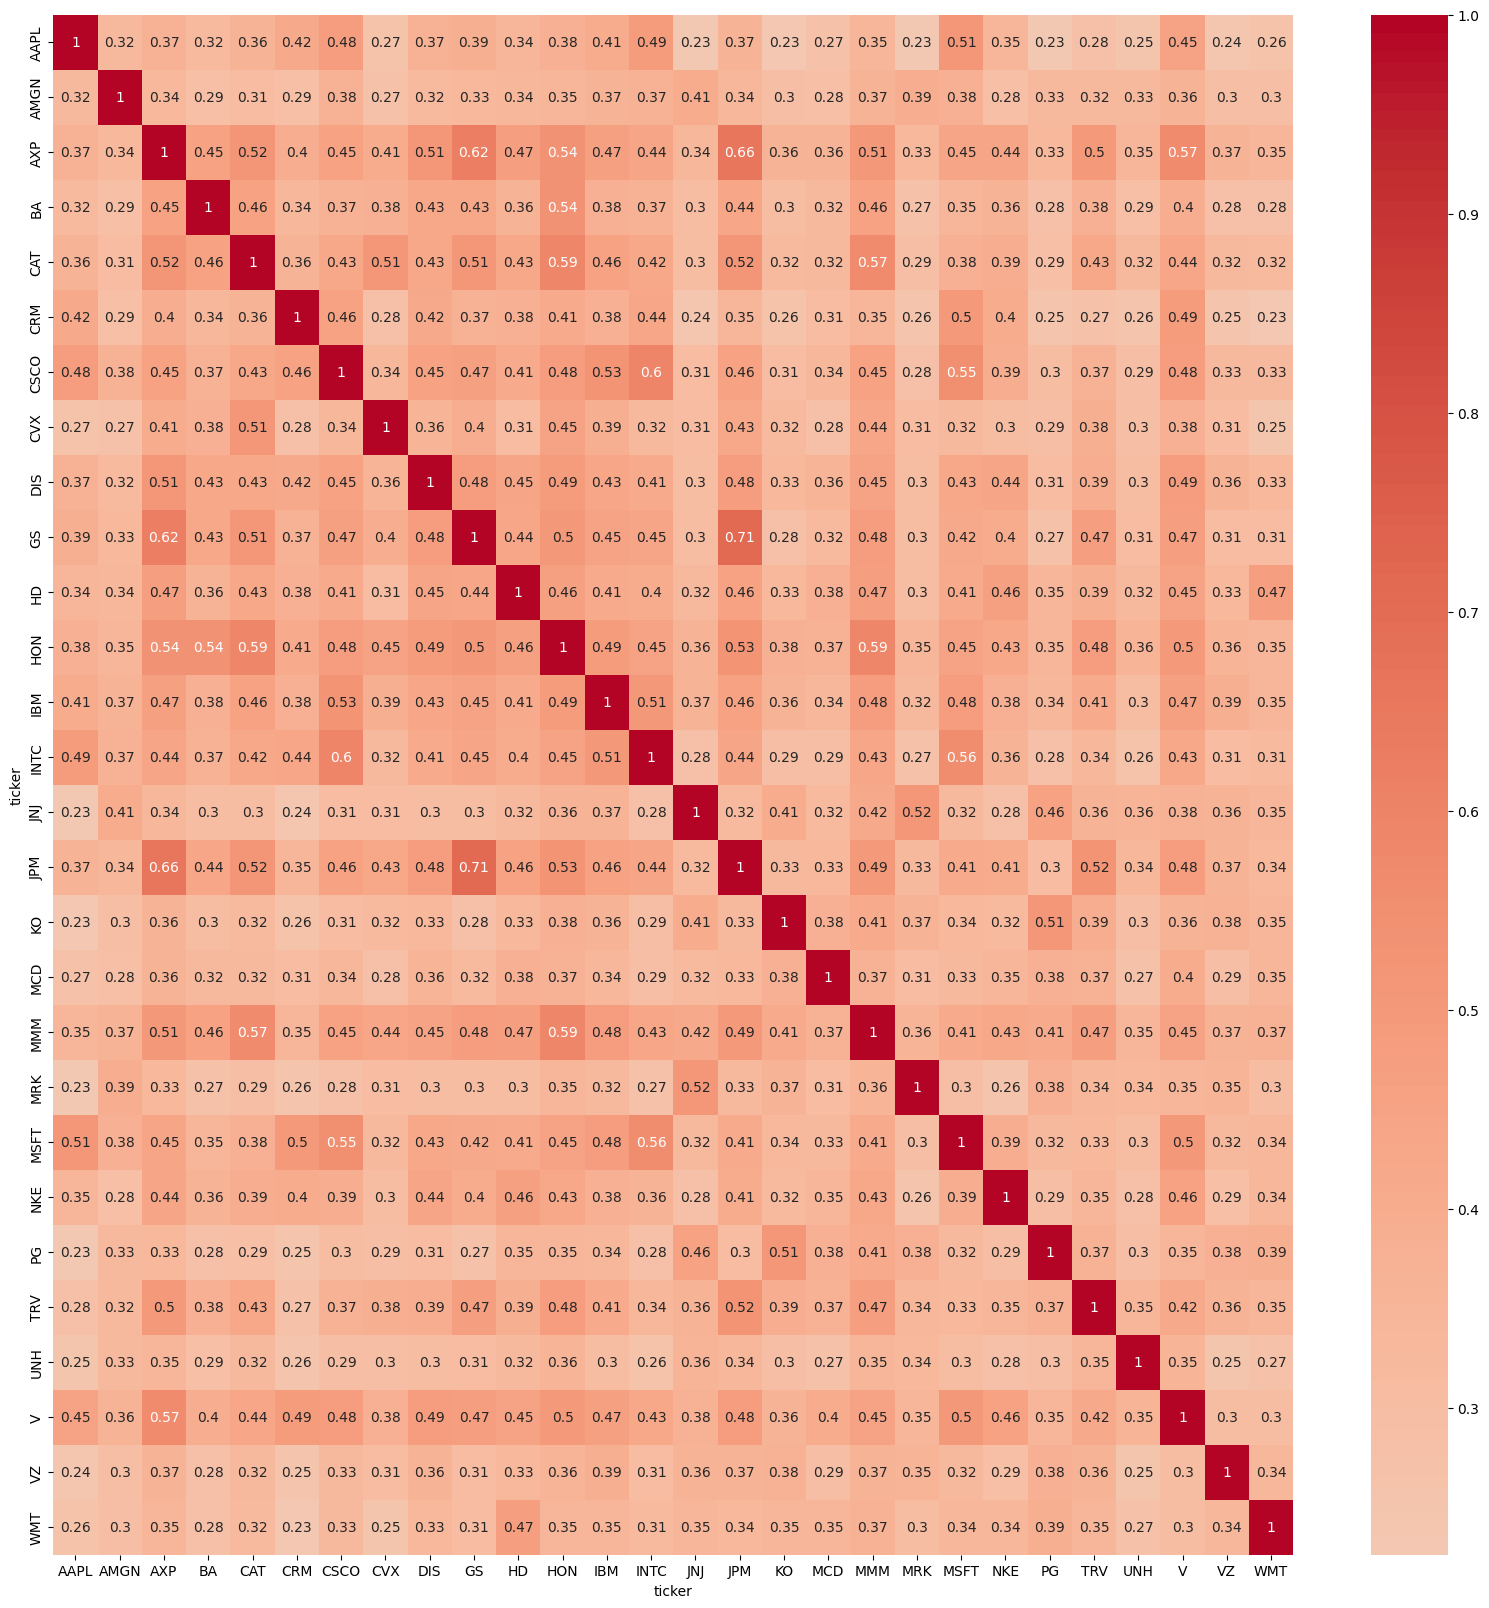

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
stock_data_file="../../../datasets/stock_data/megred_stock_data.csv"
# read the stock data
df=pd.read_csv(stock_data_file)
print("unique tickers:", df['ticker'].unique())
# Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Calculate daily close return for each ticker
df['Return'] = df.groupby('ticker')['Close'].pct_change()

# Calculate IC (Information Coefficient) for stock returns
# Pivot the table so each ticker's return is in its own column
pivot_returns = df.pivot(index='Date', columns='ticker', values='Return')

# Calculate the IC as the pairwise correlation of returns for each day
ic_values = pivot_returns.corr(method='spearman')

# Display the heatmap of IC values
plt.figure(figsize=(20, 20))
sns.heatmap(ic_values, annot=True, cmap='coolwarm', center=0)
plt.savefig("../../../datasets/stock_data/stock_return_ic_heatmap.png", bbox_inches='tight')
plt.show()


# UUP is removed as it is negative FXE
# USO is removed as there are other oil fund like BNO
# KOLD,BOIL is removed as of UNG